# VACE Pipeline Ver04

`/workspace/data/videos/_U47CbHwQ6g_13_39to339.mp4` を題材に、`/workspace/data/instructions.csv` の先頭5件を順番に適用して比較する notebook です。

この notebook では次を重視しています。

- instruction・seed・steps・checkpoint を notebook 冒頭のパラメータセルで変えられる
- 実行結果を `DataFrame` で一覧化できる
- 入力動画と出力動画を同じフレーム位置で横並び比較できる
- 画像が大きすぎて見づらくならないよう、表示サイズを notebook 側で制御する


In [1]:
from __future__ import annotations

import csv
import json
import math
import os
import shutil
import sys
from datetime import datetime
from pathlib import Path
from typing import Iterable

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('IPYTHONDIR', '/tmp/ipython')

import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, Video, display

# Thrid_Partyを優先的にインポートするためのパス設定
PROJECT_ROOT = Path('/workspace')
THIRD_PARTY_PATHS = [
    PROJECT_ROOT,
    PROJECT_ROOT / 'third_party/VACE',
    PROJECT_ROOT / 'third_party/VACE/vace',
    PROJECT_ROOT / 'third_party/Wan2.1',
    PROJECT_ROOT / 'third_party/GroundingDINO',
]
for _path in reversed(THIRD_PARTY_PATHS):
    _path_str = str(_path.resolve())
    if _path.exists() and _path_str not in sys.path:
        sys.path.insert(0, _path_str)
        
# PYTHONPATHにも同様のパスを追加
existing_pythonpath = [p for p in os.environ.get('PYTHONPATH', '').split(os.pathsep) if p]
for _path in THIRD_PARTY_PATHS:
    _path_str = str(_path.resolve())
    if _path.exists() and _path_str not in existing_pythonpath:
        existing_pythonpath.insert(0, _path_str)
os.environ['PYTHONPATH'] = os.pathsep.join(existing_pythonpath)

# 実験ログの保存先
EXPERIMENT_LOG_PATH = PROJECT_ROOT / 'docs/experiment_with_notebook.md'

# VACEの実行クラスをインポート
from src.utils.vace_executor import VaceExecutor

# Matplotlibのスタイル設定
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
pd.set_option('display.max_colwidth', 200)


## Parameters

最初にこのセルだけ調整すれば、instruction 件数・生成条件・比較表示のサイズを変えられます。

- `MAX_INSTRUCTIONS`: 何件の instruction を回すか
- `SEEDS`: seed を複数試す場合は配列で追加
- `SAMPLE_STEPS`: 品質と速度のトレードオフ
- `FRAME_NUM_OVERRIDE`: 元動画フレーム数をそのまま使うなら `None`
- `DISPLAY_FRAME_WIDTH`: 表示画像の横幅。大きすぎる場合はここを下げる


In [2]:
VIDEO_PATH = PROJECT_ROOT / 'data/videos/_U47CbHwQ6g_13_39to339.mp4'
INSTRUCTION_CSV = PROJECT_ROOT / 'data/instructions.csv'
METADATA_CSV = PROJECT_ROOT / 'data/metadata.csv'
DEFAULT_CONFIG_PATH = PROJECT_ROOT / 'configs/base.yaml'

MAX_INSTRUCTIONS = 5
SEEDS = [42]
SAMPLE_STEPS = 25
FRAME_NUM_OVERRIDE = None
RUN_TIMEOUT_SEC = 1800 # 180 -> timeoutした
PYTHON_BIN = '/usr/bin/python3'

VACE_REPO = PROJECT_ROOT / 'third_party/VACE'
VACE_CKPT_DIR = PROJECT_ROOT / 'third_party/VACE/models/VACE-Wan2.1-1.3B-Preview'

DISPLAY_FRAME_WIDTH = 4.5
DISPLAY_NUM_FRAMES = 4
OUTPUT_ROOT = PROJECT_ROOT / 'logs/notebooks/vace_pipeline_ver03'
RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')
RUN_DIR = OUTPUT_ROOT / RUN_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)

OVERWRITE_EXISTING_CASE_DIR = True


## Helpers

Notebook 内で完結して比較しやすいように、実行・メタデータ取得・比較表示の関数をまとめています。


In [3]:
def probe_video(video_path: Path) -> dict:
    """
    動画のメタデータを取得する関数
    """
    meta = iio.immeta(video_path)
    fps = float(meta.get('fps', 0) or 0)
    duration = float(meta.get('duration', 0) or 0)
    size = tuple(meta.get('size', (None, None)))
    nframes = meta.get('nframes')
    if isinstance(nframes, (int, float)) and math.isfinite(float(nframes)):
        nframes = int(nframes)
    else:
        nframes = 0
    if nframes <= 0:
        if fps > 0 and duration > 0 and math.isfinite(duration):
            nframes = int(round(fps * duration))
        else:
            frames = iio.imread(video_path, index=None)
            nframes = int(frames.shape[0])
    return {
        'video_path': str(video_path),
        'fps': fps,
        'duration': duration,
        'width': size[0],
        'height': size[1],
        'frame_count': int(nframes),
    }


def load_input_frames(video_path: Path) -> np.ndarray:
    """
    動画から全フレームを読み込む関数
    """
    frames = iio.imread(video_path, index=None)
    if frames.ndim == 3:
        frames = np.stack([frames] * 3, axis=-1)
    return frames


def sample_frame_indices(frame_count: int, num_samples: int) -> list[int]:
    """
    フレームインデックスをサンプリングする関数
    """
    if frame_count <= 0:
        return []
    num_samples = max(1, min(num_samples, frame_count))
    return np.linspace(0, frame_count - 1, num=num_samples, dtype=int).tolist()


def render_comparison(input_frames: np.ndarray, output_frames: np.ndarray, title: str, num_samples: int = DISPLAY_NUM_FRAMES, frame_width: float = DISPLAY_FRAME_WIDTH) -> None:
    """
    入力フレームと出力フレームを比較して表示する関数
    """
    sample_count = min(len(input_frames), len(output_frames))
    if sample_count == 0:
        display(Markdown(f'**{title}**\n\n比較対象のフレームがありません。'))
        return

    indices = sample_frame_indices(sample_count, num_samples)
    fig, axes = plt.subplots(2, len(indices), figsize=(frame_width * len(indices), frame_width * 1.45), dpi=110)
    if len(indices) == 1:
        axes = np.array(axes).reshape(2, 1)

    for col, idx in enumerate(indices):
        axes[0, col].imshow(input_frames[idx])
        axes[0, col].set_title(f'Input\nframe {idx}', fontsize=10)
        axes[0, col].axis('off')

        axes[1, col].imshow(output_frames[idx])
        axes[1, col].set_title(f'Output\nframe {idx}', fontsize=10)
        axes[1, col].axis('off')

    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def append_experiment_log(trial_name: str, hypothesis: str, notebook_cell: str, result: str, next_action: str) -> None:
    """
    実験ログにエントリを追加する関数
    """
    timestamp = datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')
    lines = [
        f'### {timestamp} | {trial_name}',
        '',
        f'- Hypothesis: {hypothesis}',
        f'- Notebook cell: {notebook_cell}',
        f'- Result: {result}',
        f'- Next action: {next_action}',
        '',
    ]
    EXPERIMENT_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
    with EXPERIMENT_LOG_PATH.open('a', encoding='utf-8') as f:
        f.write('\n'.join(lines))


def make_skipped_record(case_index: int, instruction: str, seed: int, frame_num: int, reason: str, case_dir: Path | None = None) -> dict:
    """
    スキップされたケースのレコードを作成する関数
    """
    return {
        'case_index': case_index,
        'seed': seed,
        'instruction': instruction,
        'status': 'skipped',
        'returncode': None,
        'timed_out': False,
        'duration_sec': 0.0,
        'output_path': None,
        'case_dir': str(case_dir) if case_dir else None,
        'sample_steps': SAMPLE_STEPS,
        'frame_num': frame_num,
        'error_msg': reason,
        'stdout': None,
        'stderr': None,
        'cmd': ['skipped'],
    }


def can_attempt_generation(preflight: dict) -> tuple[bool, str | None]:
    """
    ジェネレーションを試みることができるかを判定する関数
    """
    if preflight.get('status') != 'ok':
        return False, preflight.get('error_msg') or 'preflight failed'
    checks = preflight.get('checks', {})
    if checks.get('cuda_available') is not True:
        return False, f"CUDA is not available in the notebook kernel. checks={checks}"
    return True, None


def build_executor() -> VaceExecutor:
    """
    VaceExecutorを構築する関数
    """
    return VaceExecutor(
        vace_repo=VACE_REPO,
        vace_ckpt_dir=VACE_CKPT_DIR,
        python_bin=PYTHON_BIN,
    )


def case_slug(case_index: int, seed: int) -> str:
    """
    ケースのスラッグを生成する関数
    slugとは、ファイルシステム上で安全に使用できる識別子のことです。
    """
    return f'case_{case_index:02d}_seed_{seed}'

from src.utils.vace_edit_assets import prepare_vace_edit_assets

def run_case(
    executor: VaceExecutor,
    case_index: int,
    instruction: str,
    seed: int,
    frame_num: int,
    video_path: Path,
    sample_steps: int,
    timeout_sec: int,
) -> dict:
    """
    ケースを実行する関数
    """
    # ケースごとのディレクトリを作成
    case_dir = RUN_DIR / case_slug(case_index, seed)
    
    # 既存のディレクトリがある場合は上書きする
    if OVERWRITE_EXISTING_CASE_DIR and case_dir.exists():
        shutil.rmtree(case_dir)
    case_dir.mkdir(parents=True, exist_ok=True)

    # 追加①：mask生成
    assets = prepare_vace_edit_assets(
        video_path=video_path,
        work_dir=case_dir,
        instruction=instruction,
        edit_mode="auto",   # ← datasetはauto推定でOK
        src_ref_images=None,
    )
    # 
    output_path = case_dir / 'output.mp4'
    # 修正②：executeに渡す内容変更
    result = executor.execute(
        input_video=video_path,
        output_dir=case_dir,
        output_file=output_path,
        prompt=assets.prompt,          # ←変更
        frame_num=frame_num,
        seed=seed,
        steps=sample_steps,
        timeout_sec=timeout_sec,
        src_mask=assets.src_mask,      # ←追加（最重要）
        src_ref_images=assets.src_ref_images,
    )

    record = {
        'case_index': case_index,
        'seed': seed,
        'instruction': instruction,
        'status': result['status'],
        'returncode': result.get('returncode'),
        'timed_out': result.get('timed_out'),
        'duration_sec': result.get('duration_sec'),
        'output_path': str(result['output_path']) if result['output_path'] else None,
        'case_dir': str(case_dir),
        'sample_steps': SAMPLE_STEPS,
        'frame_num': frame_num,
        'error_msg': result['error_msg'],
        'stdout': result.get('stdout'),
        'stderr': result.get('stderr'),
        'cmd': result.get('cmd'),
    }

    (case_dir / 'run_record.json').write_text(json.dumps(record, ensure_ascii=False, indent=2), encoding='utf-8')
    return record


## Step 1. 動画と instruction の確認

まず元動画のメタデータと、今回 notebook で試す先頭5件の instruction を確定します。


In [4]:
video_meta = probe_video(VIDEO_PATH) # 動画のメタデータを取得
metadata_df = pd.read_csv(METADATA_CSV) # メタデータCSVを読み込む
instruction_df = pd.read_csv(INSTRUCTION_CSV) # 指示CSVを読み込む
selected_instructions = instruction_df.head(MAX_INSTRUCTIONS).copy() # 最初の数件の指示を選択
selected_instructions.insert(0, 'case_index', range(len(selected_instructions))) # ケースインデックスの列を追加

frame_num = int(FRAME_NUM_OVERRIDE or video_meta['frame_count']) # 使用するフレーム数を決定

display(pd.DataFrame([video_meta])) # 動画メタデータを表示
display(selected_instructions) # 選択された指示を表示

print(f'RUN_DIR: {RUN_DIR}') # ケースの出力先ディレクトリを表示
print(f'frame_num used for generation: {frame_num}') # ジェネレーションに使用するフレーム数を表示


,video_path,fps,duration,width,height,frame_count
0,/workspace/data/videos/_U47CbHwQ6g_13_39to339.mp4,25.0,5.0,1920,1080,125


,case_index,instruction_id,instruction
0,0,1,Dolly in on face
1,1,2,Raise the man's left hand
2,2,3,Wave to the camera
3,3,4,Add more exhausted animals
4,4,5,Add more rhinos


RUN_DIR: /workspace/logs/notebooks/vace_pipeline_ver03/20260323_121119
frame_num used for generation: 125


## Step 2. 入力動画プレビュー

最初に元動画そのものを確認します。動画埋め込みに加えて、比較用フレームを少数だけ抜き出して見やすいサイズで表示します。


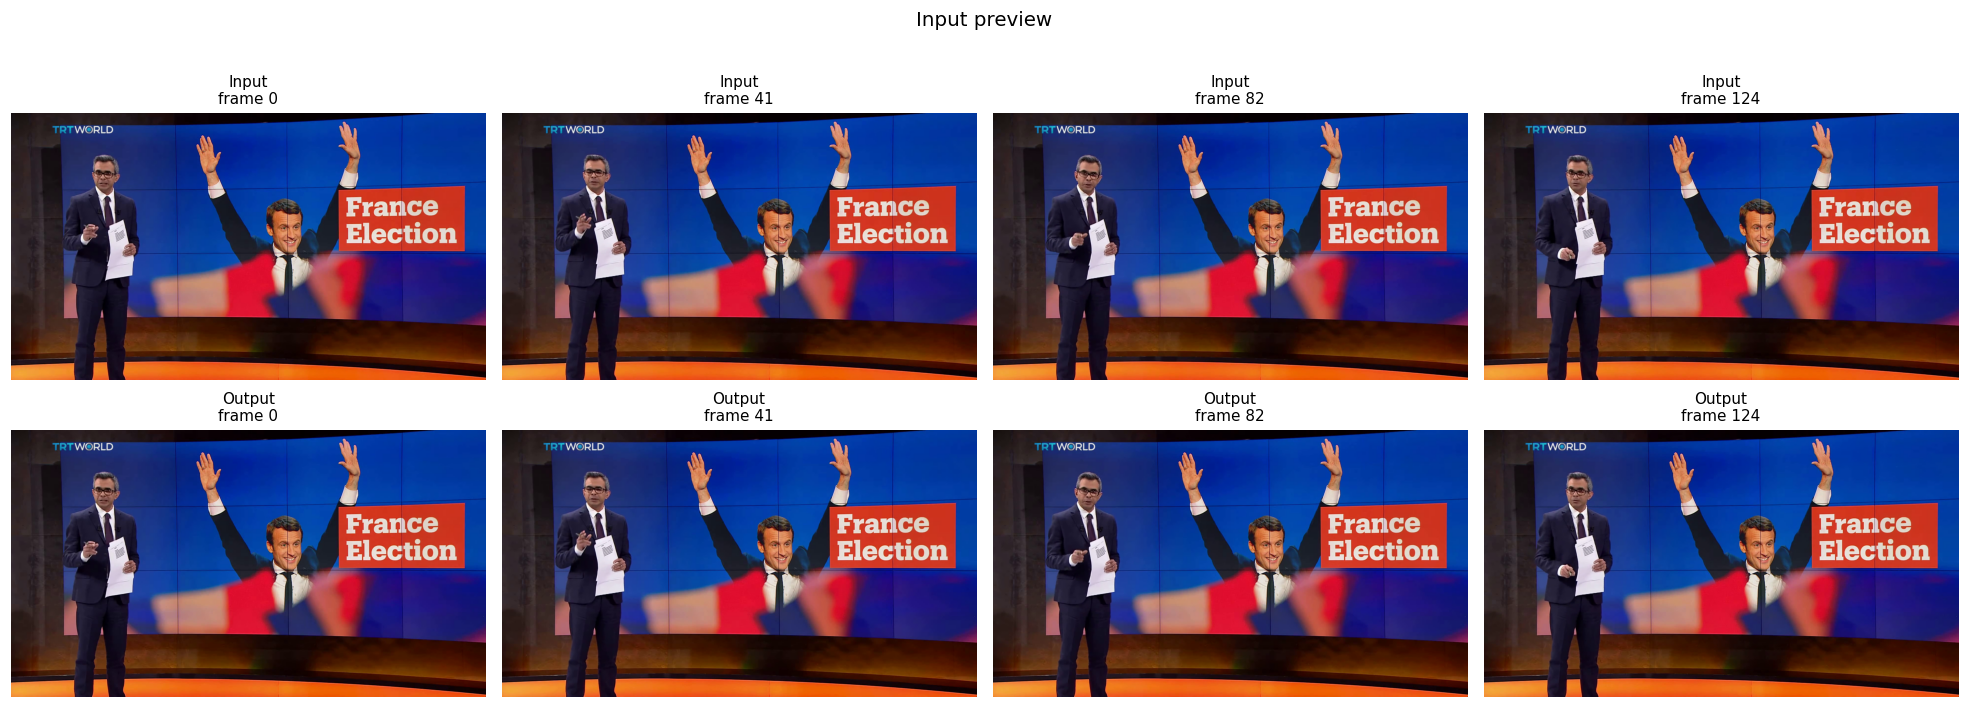

In [5]:
# ジェネレーション前の動画フレームを表示して確認
input_frames = load_input_frames(VIDEO_PATH)

# 動画を表示して確認
display(Video(str(VIDEO_PATH), embed=False, width=720))

# 入力フレームを表示して確認
render_comparison(input_frames, input_frames, title='Input preview', num_samples=DISPLAY_NUM_FRAMES, frame_width=DISPLAY_FRAME_WIDTH)


## Step 3. 実行前チェック

checkpoint や推論スクリプトの存在を先に確認します。ここが `False` の場合は、パスかモデル配置を見直してください。


In [6]:
# VACEの実行環境を構築して確認
executor = build_executor()

# VACEの実行に必要なファイルや環境が整っているかを確認
status_df = pd.DataFrame([
    {'item': 'video_exists', 'ok': VIDEO_PATH.exists(), 'path': str(VIDEO_PATH)},
    {'item': 'instruction_csv_exists', 'ok': INSTRUCTION_CSV.exists(), 'path': str(INSTRUCTION_CSV)},
    {'item': 'vace_repo_exists', 'ok': VACE_REPO.exists(), 'path': str(VACE_REPO)},
    {'item': 'checkpoint_exists', 'ok': VACE_CKPT_DIR.exists(), 'path': str(VACE_CKPT_DIR)},
    {'item': 'inference_script_exists', 'ok': executor.script_path.exists(), 'path': str(executor.script_path)},
    {'item': 'executor_available', 'ok': executor.is_available(), 'path': str(executor.vace_ckpt_dir)},
])

# ステータスを表示
display(status_df)
if not executor.is_available():
    raise RuntimeError('VACE checkpoint or inference script is missing. 上の path を確認してください。')


,item,ok,path
0,video_exists,True,/workspace/data/videos/_U47CbHwQ6g_13_39to339.mp4
1,instruction_csv_exists,True,/workspace/data/instructions.csv
2,vace_repo_exists,True,/workspace/third_party/VACE
3,checkpoint_exists,True,/workspace/third_party/VACE/models/VACE-Wan2.1-1.3B-Preview
4,inference_script_exists,True,/workspace/third_party/VACE/vace/vace_wan_inference.py
5,executor_available,True,/workspace/third_party/VACE/models/VACE-Wan2.1-1.3B-Preview


## Step 4. 先頭5 instruction を実行する

`SEEDS` を増やすと、同じ instruction に対する seed 差分もそのまま notebook 上で比較できます。


In [7]:
batch_preflight = executor.preflight()
batch_can_run, batch_skip_reason = can_attempt_generation(batch_preflight)
display(Markdown('### Batch Preflight'))
display(pd.DataFrame([{
    'status': batch_preflight['status'],
    'cuda_available': batch_preflight.get('checks', {}).get('cuda_available'),
    'device_count': batch_preflight.get('checks', {}).get('device_count'),
    'error_msg': batch_preflight.get('error_msg'),
}]))

records = []
for row in selected_instructions.itertuples(index=False):
    for seed in SEEDS:
        print(f'[RUN] case={row.case_index} seed={seed} instruction={row.instruction}')
        if batch_can_run:
            record = run_case(
                executor=executor,
                case_index=int(row.case_index),
                instruction=str(row.instruction),
                seed=int(seed),
                frame_num=frame_num,
                video_path=VIDEO_PATH,
                sample_steps=SAMPLE_STEPS,
                timeout_sec=RUN_TIMEOUT_SEC,
            )
        else:
            record = make_skipped_record(
                case_index=int(row.case_index),
                instruction=str(row.instruction),
                seed=int(seed),
                frame_num=frame_num,
                reason=batch_skip_reason or 'generation skipped',
                case_dir=RUN_DIR / case_slug(int(row.case_index), int(seed)),
            )
        records.append(record)

results_df = pd.DataFrame(records)
results_csv = RUN_DIR / 'results.csv'
results_df.to_csv(results_csv, index=False)
display(results_df)
append_experiment_log(
    trial_name='Trial 3',
    hypothesis='Batch execution should stay inside the notebook kernel and avoid hard errors when runtime requirements are missing.',
    notebook_cell='Cell 13: batch run',
    result=f"status_counts={results_df['status'].value_counts(dropna=False).to_dict()}",
    next_action='Inspect skipped / failed rows and continue with ad-hoc and easy experiment cells.',
)
print(f'saved: {results_csv}')


### Batch Preflight

,status,cuda_available,device_count,error_msg
0,ok,True,1,None


[RUN] case=0 seed=42 instruction=Dolly in on face
[RUN] case=1 seed=42 instruction=Raise the man's left hand
[RUN] case=2 seed=42 instruction=Wave to the camera
[RUN] case=3 seed=42 instruction=Add more exhausted animals


ValueError: This instruction looks like instance insertion. Provide EX_SRC_REF_IMAGES or route this case to an insertion pipeline.

## Step 5. 成功ケースだけ確認する

まずは一覧で、どの instruction が成功したか・何が失敗したかを確認します。


In [8]:
success_df = results_df.loc[results_df['status'] == 'ok'].copy()
skipped_df = results_df.loc[results_df['status'] == 'skipped'].copy()
failure_df = results_df.loc[~results_df['status'].isin(['ok', 'skipped'])].copy()

display(success_df[['case_index', 'seed', 'instruction', 'output_path', 'sample_steps', 'frame_num']])
if len(skipped_df) > 0:
    display(skipped_df[['case_index', 'seed', 'instruction', 'timed_out', 'duration_sec', 'error_msg']])
if len(failure_df) > 0:
    display(failure_df[['case_index', 'seed', 'instruction', 'returncode', 'timed_out', 'duration_sec', 'error_msg']])
else:
    print('No hard failures.')


NameError: name 'results_df' is not defined

## Step 6. 個別ケースを入力/出力で比較する

このセルの `CASE_TO_VIEW` と `SEED_TO_VIEW` を変えるだけで、任意ケースの比較ができます。


In [9]:
CASE_TO_VIEW = 0
SEED_TO_VIEW = SEEDS[0]

target_df = success_df.loc[
    (success_df['case_index'] == CASE_TO_VIEW)
    & (success_df['seed'] == SEED_TO_VIEW)
]

if target_df.empty:
    display(Markdown('**No successful run found for the selected case/seed.**'))
else:
    row = target_df.iloc[0]
    output_path = Path(row['output_path'])
    output_frames = load_input_frames(output_path)

    display(Markdown(f"**Instruction**: {row['instruction']}"))
    display(Video(str(output_path), embed=False, width=720))
    render_comparison(
        input_frames=input_frames,
        output_frames=output_frames,
        title=f'Case {CASE_TO_VIEW} / seed {SEED_TO_VIEW}',
        num_samples=DISPLAY_NUM_FRAMES,
        frame_width=DISPLAY_FRAME_WIDTH,
    )


NameError: name 'success_df' is not defined

## Step 7. 成功した全ケースをまとめて比較する

大量のフレームを出しすぎると見づらいので、各ケースともサンプルフレーム数を絞って表示します。


In [ ]:
if success_df.empty:
    display(Markdown('**No successful runs to visualize yet.**'))
else:
    for row in success_df.itertuples(index=False):
        output_frames = load_input_frames(Path(row.output_path))
        render_comparison(
            input_frames=input_frames,
            output_frames=output_frames,
            title=f'case={row.case_index} seed={row.seed} | {row.instruction}',
            num_samples=DISPLAY_NUM_FRAMES,
            frame_width=DISPLAY_FRAME_WIDTH,
        )


## Trial Notes

試行錯誤するときは次の順で触ると比較しやすいです。

- `SAMPLE_STEPS` を `15`, `25`, `35` のように振って品質と速度を見る
- `SEEDS` を `[42, 52, 62]` のように増やして安定性を見る
- `FRAME_NUM_OVERRIDE` を減らして速度優先の試行を行う
- `VACE_CKPT_DIR` を別 checkpoint に差し替えて同じ notebook を再利用する

各ケースの生ファイルは `RUN_DIR` 配下に保存されるので、あとから mp4 を直接見返せます。


## Ad-hoc: instruction を自由に指定して実行する

下の2セルを使って、任意の instruction を VACE に入力し結果をその場で確認できます。

- `USER_INSTRUCTION` に試したい指示文を入力してください
- `USER_SEED` と `USER_STEPS` を変えると生成結果も変わります
- 実行は上の Step 3 で `executor` が作成済みであることが前提です


In [10]:
# ここを書き換えて実行してください
USER_INSTRUCTION = "make the sky orange at sunset"
USER_SEED        = 42
USER_STEPS       = SAMPLE_STEPS  # 変えたい場合は整数値を直接指定 (例: 20)


[AD-HOC] instruction='make the sky orange at sunset'  seed=42  steps=25


**Instruction**: make the sky orange at sunset

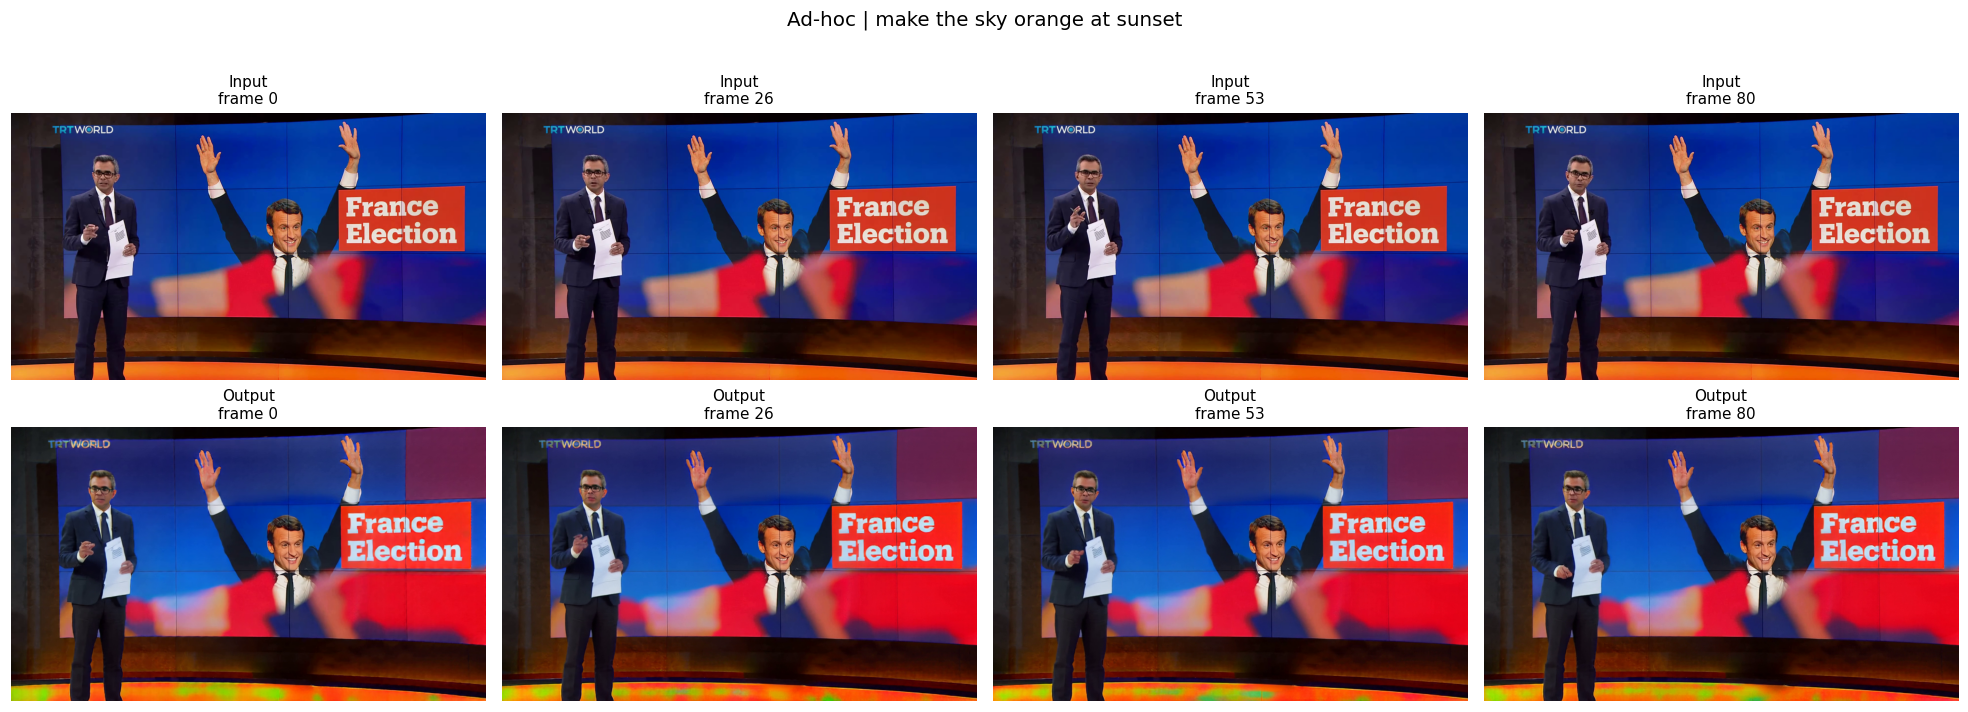

In [12]:
_ad_hoc_index = 9999  # results_df の case_index と重複しない仮インデックス

print(f'[AD-HOC] instruction={USER_INSTRUCTION!r}  seed={USER_SEED}  steps={USER_STEPS}')

_ad_hoc_preflight = executor.preflight()
_ad_hoc_can_run, _ad_hoc_skip_reason = can_attempt_generation(_ad_hoc_preflight)
if _ad_hoc_can_run:
    _ad_hoc_record = run_case(
        executor=executor,
        case_index=_ad_hoc_index,
        instruction=USER_INSTRUCTION,
        seed=USER_SEED,
        frame_num=frame_num,
        video_path=VIDEO_PATH,
        sample_steps=SAMPLE_STEPS,
        timeout_sec=RUN_TIMEOUT_SEC,
    )
else:
    _ad_hoc_record = make_skipped_record(
        case_index=_ad_hoc_index,
        instruction=USER_INSTRUCTION,
        seed=USER_SEED,
        frame_num=frame_num,
        reason=_ad_hoc_skip_reason or 'generation skipped',
    )

if _ad_hoc_record['status'] == 'ok':
    append_experiment_log(
        trial_name='Trial 4',
        hypothesis='Ad-hoc execution should degrade to skipped instead of raising when notebook runtime is not ready for generation.',
        notebook_cell='Cell 23: ad-hoc run',
        result=f"Succeeded. output_path={_ad_hoc_record.get('output_path')}",
        next_action='Inspect the generated video preview.',
    )
    _out_path = Path(_ad_hoc_record['output_path'])
    _out_frames = load_input_frames(_out_path)
    display(Markdown(f"**Instruction**: {USER_INSTRUCTION}"))
    display(Video(str(_out_path), embed=False, width=720))
    render_comparison(
        input_frames=input_frames,
        output_frames=_out_frames,
        title=f'Ad-hoc | {USER_INSTRUCTION}',
        num_samples=DISPLAY_NUM_FRAMES,
        frame_width=DISPLAY_FRAME_WIDTH,
    )
elif _ad_hoc_record['status'] == 'skipped':
    append_experiment_log(
        trial_name='Trial 4',
        hypothesis='Ad-hoc execution should degrade to skipped instead of raising when notebook runtime is not ready for generation.',
        notebook_cell='Cell 23: ad-hoc run',
        result=f"Skipped: {_ad_hoc_record['error_msg']}",
        next_action='Retry on a CUDA-visible notebook kernel or continue with environment diagnostics.',
    )
    display(Markdown(f"**SKIPPED**: {_ad_hoc_record['error_msg']}"))
else:
    append_experiment_log(
        trial_name='Trial 4',
        hypothesis='Ad-hoc execution should degrade to skipped instead of raising when notebook runtime is not ready for generation.',
        notebook_cell='Cell 23: ad-hoc run',
        result=f"Failed: {_ad_hoc_record['error_msg']}",
        next_action='Inspect stderr and adjust the in-process execution path.',
    )
    display(Markdown(f"**ERROR**: {_ad_hoc_record['error_msg']}"))
    if _ad_hoc_record.get('cmd'):
        display(Markdown(f"```bash\n{' '.join(map(str, _ad_hoc_record['cmd']))}\n```"))
    if _ad_hoc_record.get('stderr'):
        display(Markdown(f"```text\n{_ad_hoc_record['stderr'][:8000]}\n```"))


In [13]:
import os
import site
import sys
from IPython.display import Markdown, display

kernel_executor = build_executor()
added_paths = kernel_executor.ensure_runtime_paths()

print('kernel_executable =', sys.executable)
print('kernel_user_site =', site.getusersitepackages())
print('kernel_ENABLE_USER_SITE =', site.ENABLE_USER_SITE)
print('kernel_PYTHONPATH =', os.environ.get('PYTHONPATH'))
print('kernel_added_paths =', added_paths)

kernel_preflight = kernel_executor.preflight()
display(Markdown('### In-Kernel Preflight'))
display(pd.DataFrame([{
    'status': kernel_preflight['status'],
    'returncode': kernel_preflight.get('returncode'),
    'duration_sec': kernel_preflight.get('duration_sec'),
    'cuda_available': kernel_preflight.get('checks', {}).get('cuda_available'),
    'device_count': kernel_preflight.get('checks', {}).get('device_count'),
    'error_msg': kernel_preflight.get('error_msg'),
}]))
if kernel_preflight.get('stdout'):
    display(Markdown('**stdout**'))
    display(Markdown(f"```text\n{kernel_preflight['stdout'][:4000]}\n```"))
if kernel_preflight.get('stderr'):
    display(Markdown('**stderr**'))
    display(Markdown(f"```text\n{kernel_preflight['stderr'][:4000]}\n```"))

if kernel_preflight['status'] == 'ok':
    display(Markdown('**判定**: notebook カーネル内で `wan` import と CUDA 可視性確認を実施できました。'))
    append_experiment_log(
        trial_name='Trial 1',
        hypothesis='subprocess を使わず notebook カーネル内の path と import を整えれば preflight が通る。',
        notebook_cell='Cell 24: in-kernel preflight',
        result='In-kernel preflight succeeded.',
        next_action='Easy Experiment も同じカーネル内実行へ切り替えて試す。',
    )
else:
    display(Markdown('**判定**: 子プロセスではなく notebook カーネル内でも失敗しています。stderr と error を確認してください。'))
    append_experiment_log(
        trial_name='Trial 1',
        hypothesis='subprocess を使わず notebook カーネル内の path と import を整えれば preflight が通る。',
        notebook_cell='Cell 24: in-kernel preflight',
        result=f"In-kernel preflight failed: {kernel_preflight.get('error_msg')}",
        next_action='失敗要因に応じて path か import 順序を修正する。',
    )


kernel_executable = /usr/bin/python
kernel_user_site = /home/takuya/.local/lib/python3.10/site-packages
kernel_ENABLE_USER_SITE = False
kernel_PYTHONPATH = /workspace/third_party/Wan2.1:/workspace/third_party/VACE/vace:/workspace:/workspace/third_party/GroundingDINO:/workspace/third_party/VACE:/workspace/third_party/GroundingDINO:/workspace/third_party/VACE
kernel_added_paths = []


### In-Kernel Preflight

,status,returncode,duration_sec,cuda_available,device_count,error_msg
0,ok,0,0.000443,True,1,None


**stdout**

```text
python= /usr/bin/python
user_site= /home/takuya/.local/lib/python3.10/site-packages
cuda_available= True
device_count= 1
wan_file= /workspace/third_party/Wan2.1/wan/__init__.py
inference_module= /workspace/third_party/VACE/vace/vace_wan_inference.py

```

**判定**: notebook カーネル内で `wan` import と CUDA 可視性確認を実施できました。

## Easy Experiment

末尾の2セルだけで VACE の単発実験ができます。実行は subprocess ではなく notebook カーネル内の in-process 呼び出しです。

- `EX_VIDEO_INPUT` は `.mp4` パスでも動画ID/stemでも指定できます
- `EX_INSTRUCTION` は自由に変更してください
- `EX_CKPT_DIR` / `EX_SAMPLE_STEPS` / `EX_FRAME_NUM` / `EX_TIMEOUT_SEC` などをここで変更できます
- 実行結果は `logs/notebooks/vace_pipeline_ver03/manual_experiments/` 配下に保存されます


In [16]:
# ===== Easy Experiment: config =====
# 動画は .mp4 パスでも stem/ID でも指定可能です。
# 例1: EX_VIDEO_INPUT = '/workspace/data/videos/_U47CbHwQ6g_13_39to339.mp4'
# 例2: EX_VIDEO_INPUT = '_U47CbHwQ6g_13_39to339'

EX_VIDEO_INPUT = '0Th8ieWYQa0_78_0to142'
EX_INSTRUCTION = 'make the sky orange at sunset'

EX_PYTHON_BIN = '/usr/bin/python3'
EX_VACE_REPO = PROJECT_ROOT / 'third_party/VACE'
EX_CKPT_DIR = PROJECT_ROOT / 'third_party/VACE/models/VACE-Wan2.1-1.3B-Preview'

EX_SEED = 42
EX_SAMPLE_STEPS = 25
EX_FRAME_NUM = None  # None のとき入力動画のフレーム数を使用
EX_TIMEOUT_SEC = 1800

EX_OUTPUT_NAME = 'output.mp4'
EX_RUN_ROOT = PROJECT_ROOT / 'logs/notebooks/vace_pipeline_ver03/manual_experiments'
EX_SHOW_VIDEO = True
EX_SHOW_COMPARISON = True
EX_NUM_PREVIEW_FRAMES = DISPLAY_NUM_FRAMES


# 以下追加
# 重要: manual experiment では class/subclass が無いので、編集領域を明示する
# auto / background / subject / face / hair / tie / hat / subject_nearby
EX_EDIT_MODE = 'background'

# insertion 系だけ必要
EX_SRC_REF_IMAGES: list[str] = []
EX_GUIDE_SCALE = 5.0   # 追加
EX_SAMPLE_SHIFT = None # 追加



In [17]:
# ===== Easy Experiment: run =====
from datetime import datetime

from src.utils.vace_edit_assets import prepare_vace_edit_assets # 追加

def resolve_video_input(video_input: str | Path) -> Path:
    video_input = str(video_input).strip()
    direct = Path(video_input)
    if direct.exists():
        return direct.resolve()

    if video_input.endswith('.mp4'):
        candidate = (PROJECT_ROOT / video_input).resolve()
        if candidate.exists():
            return candidate

    stem = Path(video_input).stem
    candidates = [
        PROJECT_ROOT / 'data/videos' / f'{stem}.mp4',
        PROJECT_ROOT / 'videos' / f'{stem}.mp4',
    ]

    try:
        _metadata_df = pd.read_csv(METADATA_CSV)
        matched = _metadata_df[_metadata_df['video_path'].astype(str).str.contains(f'/{stem}.mp4', regex=False)]
        for p in matched['video_path'].tolist():
            candidates.append(Path(p))
    except Exception:
        pass

    seen = set()
    uniq = []
    for c in candidates:
        key = str(c)
        if key not in seen:
            uniq.append(c)
            seen.add(key)

    for c in uniq:
        if c.exists():
            return c.resolve()

    raise FileNotFoundError(
        'video not found. EX_VIDEO_INPUT should be an existing .mp4 path or a known video stem/ID. '
        f'video_input={video_input!r} candidates={[str(c) for c in uniq]}'
    )


ex_video_path = resolve_video_input(EX_VIDEO_INPUT)
ex_video_meta = probe_video(ex_video_path)
ex_frame_num = int(EX_FRAME_NUM or ex_video_meta['frame_count'])

ex_executor = VaceExecutor(
    vace_repo=Path(EX_VACE_REPO),
    vace_ckpt_dir=Path(EX_CKPT_DIR),
    python_bin=EX_PYTHON_BIN,
)

if not ex_executor.is_available():
    raise RuntimeError(
        f'VACE is not available. repo={ex_executor.vace_repo} ckpt={ex_executor.vace_ckpt_dir} script={ex_executor.script_path}'
    )

ex_run_tag = datetime.now().strftime('%Y%m%d_%H%M%S')
ex_case_dir = (Path(EX_RUN_ROOT) / ex_run_tag).resolve()
ex_case_dir.mkdir(parents=True, exist_ok=True)
ex_output_path = ex_case_dir / EX_OUTPUT_NAME

assets = prepare_vace_edit_assets(
    video_path=ex_video_path,
    work_dir=ex_case_dir,
    instruction=EX_INSTRUCTION,
    edit_mode=EX_EDIT_MODE,
    src_ref_images=EX_SRC_REF_IMAGES,
)


display(Markdown('### Experiment Config'))
display(pd.DataFrame([{
    'video_input': str(EX_VIDEO_INPUT),
    'resolved_video_path': str(ex_video_path),
    'instruction': EX_INSTRUCTION,
    'edit_mode': assets.edit_mode,
    'src_mask': str(assets.src_mask) if assets.src_mask else None,
    'src_ref_images': ','.join(assets.src_ref_images) if assets.src_ref_images else None,
    'execution_mode': 'inprocess',
    'python_bin_hint': EX_PYTHON_BIN,
    'ckpt_dir': str(Path(EX_CKPT_DIR).resolve()),
    'seed': EX_SEED,
    'sample_steps': EX_SAMPLE_STEPS,
    'guide_scale': EX_GUIDE_SCALE,
    'sample_shift': EX_SAMPLE_SHIFT,
    'frame_num': ex_frame_num,
    'output_dir': str(ex_case_dir),
}]))
display(pd.DataFrame([ex_video_meta]))

if EX_SHOW_VIDEO:
    display(Video(str(ex_video_path), embed=False, width=720))

preflight = ex_executor.preflight()
display(Markdown('### Preflight'))
display(pd.DataFrame([{
    'preflight_status': preflight['status'],
    'preflight_returncode': preflight.get('returncode'),
    'cuda_available': preflight.get('checks', {}).get('cuda_available'),
    'device_count': preflight.get('checks', {}).get('device_count'),
    'timeout_sec': EX_TIMEOUT_SEC,
    'error_msg': preflight.get('error_msg'),
}]))
if preflight.get('stdout'):
    display(Markdown('**preflight stdout**'))
    display(Markdown(f"```text\n{preflight['stdout'][:4000]}\n```"))
if preflight.get('stderr'):
    display(Markdown('**preflight stderr**'))
    display(Markdown(f"```text\n{preflight['stderr'][:4000]}\n```"))

ex_can_run, ex_skip_reason = can_attempt_generation(preflight)

if preflight['status'] != 'ok':
    ex_result = {
        'status': 'error',
        'returncode': preflight.get('returncode'),
        'timed_out': False,
        'duration_sec': preflight.get('duration_sec', 0.0),
        'output_path': None,
        'error_msg': preflight.get('error_msg') or 'Preflight failed before VACE run. See preflight stderr.',
        'cmd': ['inprocess-preflight'],
        'stdout': preflight.get('stdout'),
        'stderr': preflight.get('stderr'),
    }
elif not ex_can_run:
    ex_result = {
        'status': 'skipped',
        'returncode': None,
        'timed_out': False,
        'duration_sec': 0.0,
        'output_path': None,
        'error_msg': ex_skip_reason,
        'cmd': ['skipped'],
        'stdout': preflight.get('stdout'),
        'stderr': preflight.get('stderr'),
    }
else:
    ex_result = ex_executor.execute(
        input_video=ex_video_path,
        output_dir=ex_case_dir,
        output_file=ex_output_path,
        prompt=assets.prompt,
        frame_num=ex_frame_num,
        seed=EX_SEED,
        steps=EX_SAMPLE_STEPS,
        timeout_sec=EX_TIMEOUT_SEC,
        src_mask=assets.src_mask,
        src_ref_images=assets.src_ref_images,
        guide_scale=EX_GUIDE_SCALE,
        sample_shift=EX_SAMPLE_SHIFT,
    )

display(Markdown('### Experiment Result'))
display(pd.DataFrame([{
    'status': ex_result['status'],
    'returncode': ex_result.get('returncode'),
    'timed_out': ex_result.get('timed_out'),
    'duration_sec': ex_result.get('duration_sec'),
    'output_path': str(ex_result['output_path']) if ex_result['output_path'] else None,
    'src_mask_artifact': ex_result.get('artifacts', {}).get('src_mask'),
    'src_video_artifact': ex_result.get('artifacts', {}).get('src_video'),
    'out_video_artifact': ex_result.get('artifacts', {}).get('out_video'),
    'error_msg': ex_result['error_msg'],
}]))
if ex_result.get('cmd'):
    display(Markdown('**command**'))
    display(Markdown(f'```bash\n{" ".join(map(str, ex_result["cmd"]))}\n```'))
if ex_result.get('stdout'):
    display(Markdown('**stdout**'))
    display(Markdown(f'```text\n{ex_result["stdout"][:8000]}\n```'))
if ex_result.get('stderr'):
    display(Markdown('**stderr**'))
    display(Markdown(f'```text\n{ex_result["stderr"][:8000]}\n```'))

if ex_result['status'] == 'ok':
    append_experiment_log(
        trial_name='Trial 2',
        hypothesis='Easy Experiment も notebook カーネル内の in-process 実行へ切り替えれば subprocess なしで完走できる。',
        notebook_cell='Cell 27: easy experiment run',
        result=f"Succeeded. output_path={ex_result.get('output_path')}",
        next_action='必要なら追加ケースでも再確認する。',
    )
    if EX_SHOW_VIDEO:
        display(Video(str(ex_output_path), embed=False, width=720))

    if EX_SHOW_COMPARISON:
        ex_input_frames = load_input_frames(ex_video_path)
        ex_output_frames = load_input_frames(ex_output_path)
        render_comparison(
            input_frames=ex_input_frames,
            output_frames=ex_output_frames,
            title=f'Easy Experiment | {EX_INSTRUCTION}',
            num_samples=EX_NUM_PREVIEW_FRAMES,
            frame_width=DISPLAY_FRAME_WIDTH,
        )
elif ex_result['status'] == 'skipped':
    append_experiment_log(
        trial_name='Trial 2',
        hypothesis='Easy Experiment も notebook カーネル内の in-process 実行へ切り替えれば subprocess なしで完走できる。',
        notebook_cell='Cell 27: easy experiment run',
        result=f"Skipped: {ex_result['error_msg']}",
        next_action='CUDA が見える notebook カーネルで再実行する。',
    )
    display(Markdown(f"**SKIPPED**: {ex_result['error_msg']}"))
else:
    append_experiment_log(
        trial_name='Trial 2',
        hypothesis='Easy Experiment も notebook カーネル内の in-process 実行へ切り替えれば subprocess なしで完走できる。',
        notebook_cell='Cell 27: easy experiment run',
        result=f"Failed: {ex_result['error_msg']}",
        next_action='エラー内容に応じて notebook セルと in-process 実行ラッパを修正する。',
    )
    display(Markdown(f"**ERROR**: {ex_result['error_msg']}"))


### Experiment Config

,video_input,resolved_video_path,instruction,edit_mode,src_mask,src_ref_images,execution_mode,python_bin_hint,ckpt_dir,seed,sample_steps,guide_scale,sample_shift,frame_num,output_dir
0,0Th8ieWYQa0_78_0to142,/workspace/data/videos/0Th8ieWYQa0_78_0to142.mp4,make the sky orange at sunset,background,/workspace/logs/notebooks/vace_pipeline_ver03/manual_experiments/20260323_133512/src_mask.mp4,None,inprocess,/usr/bin/python3,/workspace/third_party/VACE/models/VACE-Wan2.1-1.3B-Preview,42,25,5.0,None,125,/workspace/logs/notebooks/vace_pipeline_ver03/manual_experiments/20260323_133512


,video_path,fps,duration,width,height,frame_count
0,/workspace/data/videos/0Th8ieWYQa0_78_0to142.mp4,25.0,5.0,1920,1080,125


### Preflight

,preflight_status,preflight_returncode,cuda_available,device_count,timeout_sec,error_msg
0,ok,0,True,1,1800,None


**preflight stdout**

```text
python= /usr/bin/python
user_site= /home/takuya/.local/lib/python3.10/site-packages
cuda_available= True
device_count= 1
wan_file= /workspace/third_party/Wan2.1/wan/__init__.py
inference_module= /workspace/third_party/VACE/vace/vace_wan_inference.py

```

UnboundLocalError: local variable 'module_ret' referenced before assignment

In [ ]:
# ===== Notebook Debug Summary =====
display(Markdown('### Latest Experiment Log'))
if EXPERIMENT_LOG_PATH.exists():
    _log_text = EXPERIMENT_LOG_PATH.read_text(encoding='utf-8')
    display(Markdown(f"```text\n{_log_text[-4000:]}\n```"))
else:
    display(Markdown('No experiment log file found yet.'))

display(Markdown('### Status Snapshot'))
if 'results_df' in globals():
    display(results_df['status'].value_counts(dropna=False).rename_axis('status').reset_index(name='count'))
else:
    display(Markdown('`results_df` is not available yet.'))

if 'ex_result' in globals():
    display(pd.DataFrame([{
        'status': ex_result.get('status'),
        'timed_out': ex_result.get('timed_out'),
        'output_path': ex_result.get('output_path'),
        'error_msg': ex_result.get('error_msg'),
    }]))
else:
    display(Markdown('`ex_result` is not available yet.'))
